In [ ]:
import pandas as pd
import numpy as np
file_path = "/content/drive/MyDrive/Colab Notebooks/Mobile Reviews Sentiment null.csv"
df = pd.read_csv(file_path)

In [ ]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")
print(df.info())

Rows: 50000, Columns: 22

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   review_id             50000 non-null  int64  
 1   customer_name         50000 non-null  object 
 2   age                   50000 non-null  int64  
 3   brand                 50000 non-null  object 
 4   model                 50000 non-null  object 
 5   price_usd             47550 non-null  float64
 6   price_local           47569 non-null  object 
 7   currency              50000 non-null  object 
 8   exchange_rate_to_usd  50000 non-null  float64
 9   rating                47547 non-null  float64
 10  sentiment             47555 non-null  object 
 11  country               50000 non-null  object 
 12  language              50000 non-null  object 
 13  review_date           50000 non-null  object 
 14  verified_purchase     50000 non-null  bool  

In [ ]:
df.head(5)

,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
0,1,Aryan Maharaj,45,Realme,Realme 12 Pro,337.31,₹27996.73,INR,83.00,2.0,...,Hindi,11/6/2023,True,1,1,3,2,1,1,Amazon
1,2,Davi Miguel Sousa,18,Realme,Realme 12 Pro,307.78,R$1754.35,BRL,5.70,4.0,...,Portuguese,3/30/2023,True,3,2,4,3,2,5,Flipkart
2,3,Pahal Balay,27,Google,Pixel 6,864.53,₹71755.99,INR,83.00,4.0,...,Hindi,12/7/2022,True,3,5,3,2,4,8,AliExpress
3,4,David Guzman,19,Xiaomi,Redmi Note 13,660.94,د.إ2425.65,AED,3.67,3.0,...,English,3/11/2025,False,1,3,2,1,2,3,Amazon
4,5,Yago Leão,38,Motorola,Edge 50,792.13,R$4515.14,BRL,5.70,3.0,...,Portuguese,9/29/2023,True,3,3,2,2,1,0,BestBuy


In [ ]:
df.describe(include='all')

,review_id,customer_name,age,brand,model,price_usd,price_local,currency,exchange_rate_to_usd,rating,...,language,review_date,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source
count,50000.000000,50000,50000.000000,50000,50000,47550.00000,47569,50000,50000.000000,47547.000000,...,50000,50000,50000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,47552
unique,NaN,45911,NaN,7,22,NaN,46127,8,NaN,NaN,...,4,1096,2,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,Michael Smith,NaN,Xiaomi,Realme Narzo 70,NaN,R$2272.3,USD,NaN,NaN,...,English,4/5/2023,True,NaN,NaN,NaN,NaN,NaN,NaN,eBay
freq,NaN,16,NaN,7241,3597,NaN,4,6435,NaN,NaN,...,31295,67,40070,NaN,NaN,NaN,NaN,NaN,NaN,9573
mean,25000.500000,NaN,30.075220,NaN,NaN,689.89277,NaN,NaN,12.057946,3.123415,...,NaN,NaN,NaN,2.71800,2.717640,2.719620,2.713960,2.721280,3.644180,NaN
std,14433.901067,NaN,8.931307,NaN,NaN,310.32722,NaN,NaN,26.553332,1.249067,...,NaN,NaN,NaN,1.34827,1.345001,1.349208,1.343346,1.352121,2.432745,NaN
min,1.000000,NaN,18.000000,NaN,NaN,180.02000,NaN,NaN,0.780000,1.000000,...,NaN,NaN,NaN,1.00000,1.000000,1.000000,1.000000,1.000000,0.000000,NaN
25%,12500.750000,NaN,23.000000,NaN,NaN,450.75500,NaN,NaN,1.000000,2.000000,...,NaN,NaN,NaN,1.00000,1.000000,1.000000,1.000000,1.000000,2.000000,NaN
50%,25000.500000,NaN,29.000000,NaN,NaN,637.58500,NaN,NaN,1.530000,3.000000,...,NaN,NaN,NaN,3.00000,3.000000,3.000000,3.000000,3.000000,3.000000,NaN
75%,37500.250000,NaN,36.000000,NaN,NaN,901.45750,NaN,NaN,5.700000,4.000000,...,NaN,NaN,NaN,4.00000,4.000000,4.000000,4.000000,4.000000,5.000000,NaN


In [ ]:
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
print(f" Removed {initial_rows - df.shape[0]} duplicate rows.")

 Removed 0 duplicate rows.


In [ ]:
df = df[df['brand'].notna() & ~df['brand'].str.contains('null', case=False, na=False)]

In [ ]:
spec_cols = ['battery_life_rating', 'camera_rating', 'performance_rating', 'design_rating', 'display_rating']
for col in spec_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

In [ ]:
df['price_usd'] = pd.to_numeric(df['price_usd'], errors='coerce')
df['price_usd'] = df['price_usd'].fillna(df['price_usd'].median())

In [ ]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['age'] = pd.to_numeric(df['age'], errors='coerce')

In [ ]:
df['helpful_votes'] = pd.to_numeric(df['helpful_votes'], errors='coerce').fillna(0)
df['verified_multiplier'] = df['verified_purchase'].apply(lambda x: 1.5 if str(x).upper() == 'TRUE' else 1.0)
df['engagement_score'] = df['helpful_votes'] * df['verified_multiplier']

In [ ]:
features_list = ['price_usd', 'rating', 'battery_life_rating', 'camera_rating', 'performance_rating', 'design_rating', 'display_rating', 'engagement_score']
df_features = df[features_list].copy()

print("\n--- Processed Feature Dataset Summary ---")
print(df_features.info())
print(df_features.head())


--- Processed Feature Dataset Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price_usd            50000 non-null  float64
 1   rating               47547 non-null  float64
 2   battery_life_rating  50000 non-null  int64  
 3   camera_rating        50000 non-null  int64  
 4   performance_rating   50000 non-null  int64  
 5   design_rating        50000 non-null  int64  
 6   display_rating       50000 non-null  int64  
 7   engagement_score     50000 non-null  float64
dtypes: float64(3), int64(5)
memory usage: 3.1 MB
None
   price_usd  rating  battery_life_rating  camera_rating  performance_rating  \
0     337.31     2.0                    1              1                   3   
1     307.78     4.0                    3              2                   4   
2     864.53     4.0                    3             

In [ ]:
from sklearn.preprocessing import StandardScaler
print("=== Encoding and Scaling Dataset ===")
categorical_cols = ['brand', 'country', 'model']
numerical_cols = ['price_usd', 'rating', 'battery_life_rating', 'camera_rating',
                  'performance_rating', 'design_rating', 'display_rating', 'engagement_score']
df_model = df[categorical_cols + numerical_cols].copy()
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
df_encoded_clean = df_encoded.dropna()
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_encoded_clean)
df_scaled = pd.DataFrame(scaled_data, columns=df_encoded_clean.columns)

print("\n--- Final Scaled Dataset Shape ---")
print(df_scaled.shape)
print("\n--- First 3 Rows of Scaled Features ---")
print(df_scaled.head(3))

=== Encoding and Scaling Dataset ===

--- Final Scaled Dataset Shape ---
(47547, 42)

--- First 3 Rows of Scaled Features ---
   price_usd    rating  battery_life_rating  camera_rating  \
0  -1.155787 -0.899412            -1.274740      -1.277838   
1  -1.253292  0.701799             0.208456      -0.534583   
2   0.585043  0.701799             0.208456       1.695181   

   performance_rating  design_rating  display_rating  engagement_score  \
0            0.207677      -0.531273       -1.273766         -1.025527   
1            0.949221       0.212644       -0.533957          0.680234   
2            0.207677      -0.531273        0.945662          1.959554   

   brand_Google  brand_Motorola  ...  model_Pixel 8  model_Poco X6  \
0     -0.410370       -0.405706  ...      -0.223859      -0.220051   
1     -0.410370       -0.405706  ...      -0.223859      -0.220051   
2      2.436828       -0.405706  ...      -0.223859      -0.220051   

   model_Razr 40  model_Realme 12 Pro  model_Re


[1] Product Distribution Across Brands:
brand
Xiaomi      7241
Google      7234
Apple       7144
OnePlus     7136
Realme      7132
Motorola    7061
Samsung     7052
Name: count, dtype: int64

Product Distribution Across Countries:
country
USA          6435
Brazil       6419
UAE          6261
Australia    6219
UK           6210
Canada       6170
Germany      6162
India        6124
Name: count, dtype: int64


/tmp/ipykernel_1746/3063420562.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='brand', order=brand_counts.index, palette='viridis')


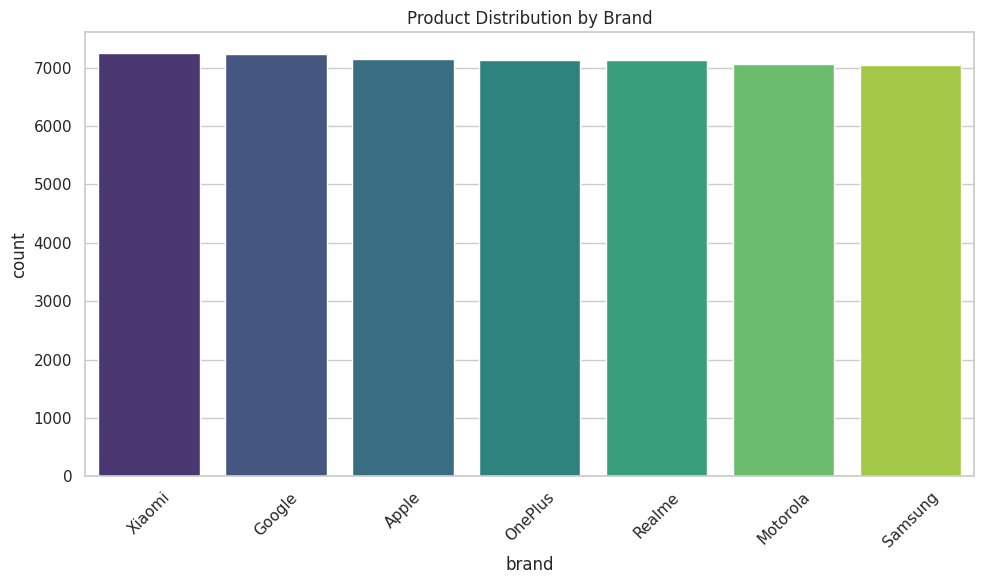

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
# Analyze Product Distribution
print("\n[1] Product Distribution Across Brands:")
brand_counts = df['brand'].value_counts()
print(brand_counts)

print("\nProduct Distribution Across Countries:")
country_counts = df['country'].value_counts()
print(country_counts)
plt.figure()
sns.countplot(data=df, x='brand', order=brand_counts.index, palette='viridis')
plt.title('Product Distribution by Brand')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print("\n[2] Top 5 Highest-Rated Smartphone Models:")
top_rated = df.sort_values(by=['rating', 'engagement_score'], ascending=False)
print(top_rated[['brand', 'model', 'rating', 'price_usd']].head(5))

print("\nBottom 5 Lowest-Rated Smartphone Models:")
low_rated = df.sort_values(by=['rating', 'engagement_score'], ascending=True)
print(low_rated[['brand', 'model', 'rating', 'price_usd']].head(5))




[2] Top 5 Highest-Rated Smartphone Models:
          brand          model  rating  price_usd
29766  Motorola        Razr 40     5.0     565.28
4468      Apple      iPhone 13     5.0    1288.06
16527     Apple      iPhone 14     5.0    1021.88
21320  Motorola   Moto G Power     5.0     337.16
23884     Apple  iPhone 15 Pro     5.0    1114.49

Bottom 5 Lowest-Rated Smartphone Models:
        brand            model  rating  price_usd
30     Realme  Realme Narzo 70     1.0    298.000
51      Apple        iPhone 14     1.0    637.585
118    Xiaomi        Mi 13 Pro     1.0    638.330
237    Realme    Realme 12 Pro     1.0    455.950
247  Motorola          Edge 50     1.0    654.370


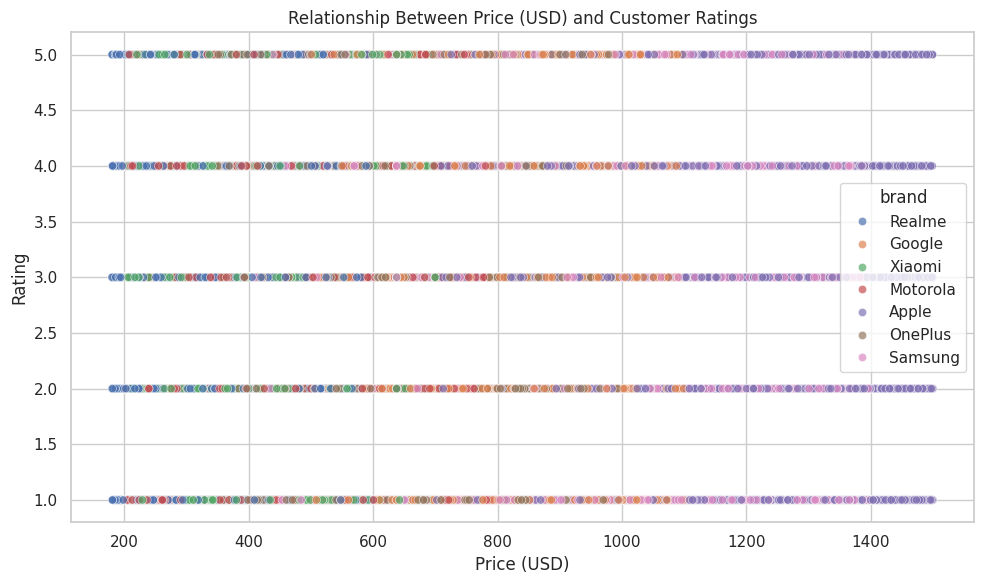

In [ ]:
# scatter plot to view Price vs. Overall Rating
plt.figure()
sns.scatterplot(data=df, x='price_usd', y='rating', hue='brand', alpha=0.7)
plt.title('Relationship Between Price (USD) and Customer Ratings')
plt.xlabel('Price (USD)')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()


[4] Correlation Matrix Summary (Relationships between metrics):
rating                 1.000000
battery_life_rating    0.762147
camera_rating          0.760083
display_rating         0.757411
performance_rating     0.755611
design_rating          0.755272
engagement_score       0.445903
price_usd              0.004438
Name: rating, dtype: float64


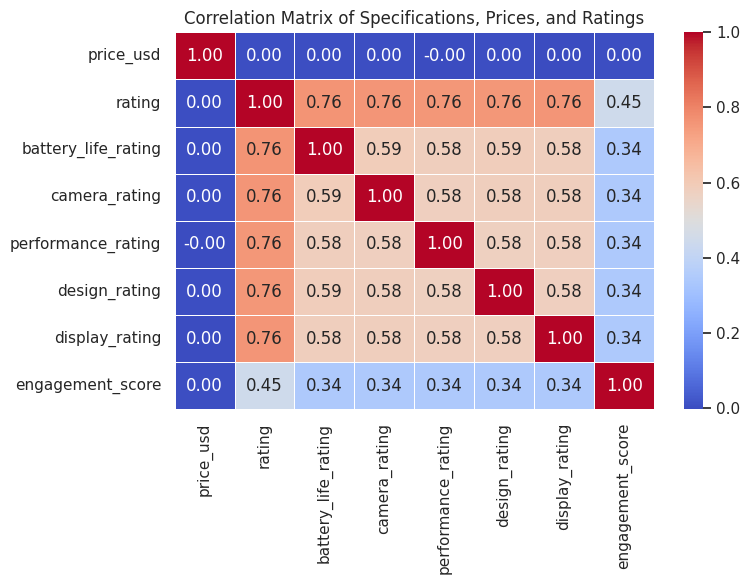

In [ ]:
#Identify Patterns, Trends, and Correlations
numerical_cols = ['price_usd', 'rating', 'battery_life_rating', 'camera_rating',
                  'performance_rating', 'design_rating', 'display_rating', 'engagement_score']

correlation_matrix = df[numerical_cols].corr()

print("\n[4] Correlation Matrix Summary (Relationships between metrics):")
print(correlation_matrix['rating'].sort_values(ascending=False))

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Specifications, Prices, and Ratings')
plt.tight_layout()
plt.show()



In [ ]:
print("\n[5] Average Price and Rating by Brand Tier:")
brand_summary = df.groupby('brand').agg({
    'price_usd': 'mean',
    'rating': 'mean',
    'performance_rating': 'mean'
}).reset_index()
print(brand_summary.sort_values(by='price_usd', ascending=False))


[5] Average Price and Rating by Brand Tier:
      brand    price_usd    rating  performance_rating
0     Apple  1080.211223  3.132340            2.720465
5   Samsung   887.753756  3.113390            2.704481
1    Google   797.459574  3.124763            2.702516
3   OnePlus   670.331866  3.131854            2.723515
2  Motorola   512.702461  3.109970            2.717179
6    Xiaomi   458.754478  3.114539            2.715233
4    Realme   405.871000  3.136906            2.754066


In [ ]:
from sklearn.cluster import KMeans

print("=== WCSS (Within-Cluster Sum of Squares) Values ===")

wcss = []
cluster_range = range(1, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

print(f"{'Clusters (K)':<15}{'WCSS Value':<20}{'Reduction Rate':<15}")
print("-" * 50)

for i in range(len(wcss)):
    k = cluster_range[i]
    val = wcss[i]

    if i == 0:
        reduction = "Baseline"
    else:
        pct_drop = ((wcss[i-1] - val) / wcss[i-1]) * 100
        reduction = f"-{pct_drop:.1f}%"

    print(f"{k:<15}{val:<20.2f}{reduction:<15}")

=== WCSS (Within-Cluster Sum of Squares) Values ===
Clusters (K)   WCSS Value          Reduction Rate 
--------------------------------------------------
1              1996974.00          Baseline       
2              1839564.78          -7.9%          
3              1754085.01          -4.6%          
4              1671296.27          -4.7%          
5              1582686.31          -5.3%          
6              1485614.48          -6.1%          
7              1452680.71          -2.2%          
8              1348689.82          -7.2%          
9              1298685.95          -3.7%          
10             1248037.99          -3.9%          


=== Starting Step 4: Clustering (Segmentation Analysis) ===


/tmp/ipykernel_31963/65375626.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_encoded_clean['Cluster'] = cluster_labels


✓ K-Means model successfully trained and assigned to matching rows.

--- Summary Profile of Each Cluster ---
   Cluster   price_usd    rating  performance_rating  camera_rating  \
0        0  888.425290  3.113390            2.703671       2.706197   
1        1  458.383812  3.114539            2.715616       2.721729   
2        2  694.191461  2.095755            1.772551       1.767715   
3        3  693.480873  4.131949            3.650907       3.650268   

   battery_life_rating  product_count  
0             2.715262           6729  
1             2.712123           6871  
2             1.765148          16751  
3             3.652128          17196  


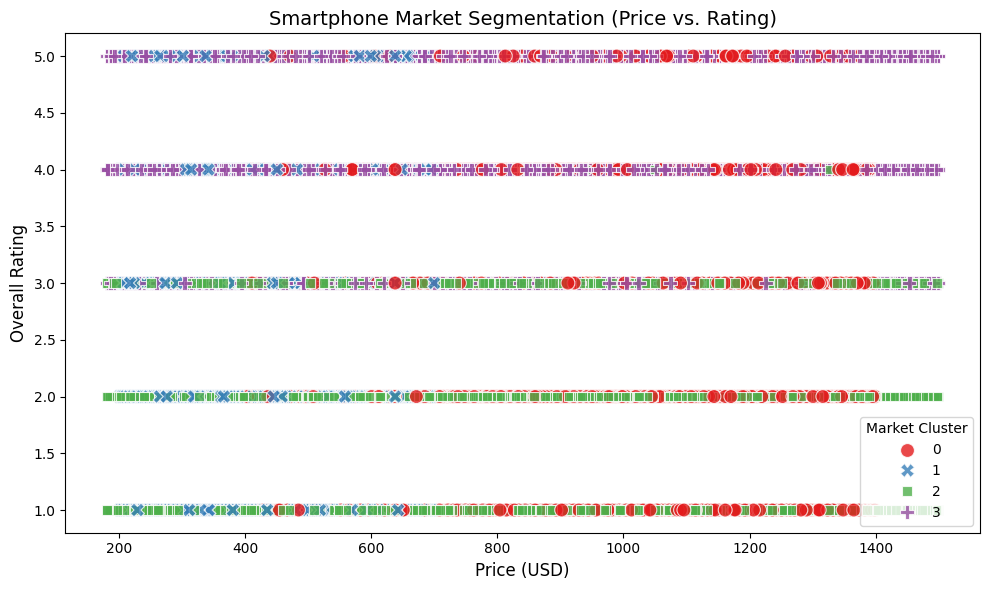

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

print("=== Starting Step 4: Clustering (Segmentation Analysis) ===")

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_scaled)
df_encoded_clean['Cluster'] = cluster_labels

df_clean = df.loc[df_encoded_clean.index].copy()
df_clean['Cluster'] = cluster_labels

print(" K-Means model successfully trained and assigned to matching rows.")

cluster_profile = df_clean.groupby('Cluster').agg({
    'price_usd': 'mean',
    'rating': 'mean',
    'performance_rating': 'mean',
    'camera_rating': 'mean',
    'battery_life_rating': 'mean',
    'review_id': 'count'
}).rename(columns={'review_id': 'product_count'}).reset_index()

print("\n--- Summary Profile of Each Cluster ---")
print(cluster_profile)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x='price_usd',
    y='rating',
    hue='Cluster',
    palette='Set1',
    alpha=0.8,
    style='Cluster',
    s=100
)

plt.title('Smartphone Market Segmentation (Price vs. Rating)', fontsize=14)
plt.xlabel('Price (USD)', fontsize=12)
plt.ylabel('Overall Rating', fontsize=12)
plt.legend(title='Market Cluster')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

print("=== Starting Step 5: Memory-Optimized Recommendation System ===")

categorical_cols = ['brand', 'country', 'model']
numerical_cols = ['price_usd', 'rating', 'battery_life_rating', 'camera_rating',
                  'performance_rating', 'design_rating', 'display_rating', 'engagement_score']

df_model = df[categorical_cols + numerical_cols].copy()
df_encoded_clean = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True).dropna()

scaler = StandardScaler()
df_scaled_data = scaler.fit_transform(df_encoded_clean)

df_original_reset = df.loc[df_encoded_clean.index].copy().reset_index(drop=True)
df_original_reset['full_product_name'] = df_original_reset['brand'] + " " + df_original_reset['model']
df_original_reset['Cluster'] = df_clean.loc[df_encoded_clean.index,'Cluster'].values

def get_smartphone_recommendations(product_title, num_recommendations=5):
    """
    Finds recommendations by computing similarity ONLY for the requested item.
    Uses virtually 0 RAM.
    """
    matching_indices = df_original_reset[df_original_reset['full_product_name'].str.contains(product_title, case=False, na=False)].index

    if len(matching_indices) == 0:
        return f" Product matching '{product_title}' not found. Please verify spelling."

    target_idx = matching_indices[0]
    target_vector = df_scaled_data[target_idx].reshape(1, -1)

    similarity_scores = cosine_similarity(target_vector, df_scaled_data).flatten()

    sorted_indices = np.argsort(similarity_scores)[::-1]
    sorted_indices = [idx for idx in sorted_indices if idx != target_idx][:num_recommendations]

    recommended_items = []
    for idx in sorted_indices:
        item_details = {
            'Recommended Product': df_original_reset.loc[idx, 'full_product_name'],
            'Price (USD)': df_original_reset.loc[idx, 'price_usd'],
            'Rating': df_original_reset.loc[idx, 'rating'],
            'Market Cluster': df_original_reset.loc[idx, 'Cluster'] if 'Cluster' in df_original_reset.columns else "N/A",
            'Match Accuracy': f"{similarity_scores[idx] * 100:.1f}%"
        }
        recommended_items.append(item_details)

    return pd.DataFrame(recommended_items)

print("\n--- Generating System Recommendations Test ---")
recommend_df = get_smartphone_recommendations('Apple', num_recommendations=5)
print(recommend_df)

=== Starting Step 5: Memory-Optimized Recommendation System ===

--- Generating System Recommendations Test ---
  Recommended Product  Price (USD)  Rating  Market Cluster Match Accuracy
0     Apple iPhone 14       719.60     5.0               3          98.7%
1     Apple iPhone 14       993.81     5.0               3          98.7%
2     Apple iPhone 14       784.77     5.0               3          98.6%
3     Apple iPhone 14       880.78     5.0               3          98.1%
4     Apple iPhone 14       870.35     5.0               3          98.1%


In [ ]:
!pip install streamlit plotly pyngrok --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 61.8 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

st.set_page_config(page_title="Smartphone Market & Recommendation Dashboard", layout="wide")
st.title(" Smartphone Market Segmentation & Recommendation Engine")
st.markdown("An interactive application displaying product clusters, market analytics, and similarity-based product recommendations.")

@st.cache_data
def load_and_preprocess_data():
    """Loads dataset and performs the core pipeline steps securely."""
    try:
        data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Mobile Reviews Sentiment null.csv')
    except FileNotFoundError:

        st.warning(" 'smartphone_reviews.csv' not found. Creating simulated sample dataset for demo.")
        np.random.seed(42)
        brands = ['Apple', 'Samsung', 'Google', 'Realme', 'Xiaomi']
        countries = ['India', 'USA', 'Germany', 'Brazil', 'UAE']
        models = ['iPhone 14', 'Galaxy S23', 'Pixel 7', 'GT Neo 5', 'Redmi Note 12']

        simulated_data = []
        for i in range(1000):
            b = np.random.choice(brands)
            simulated_data.append({
                'review_id': f"REV_{i}", 'brand': b, 'model': f"{b} {np.random.choice(models)}",
                'country': np.random.choice(countries), 'price_usd': np.random.uniform(150, 1200),
                'rating': np.random.uniform(1.0, 5.0), 'battery_life_rating': np.random.uniform(1.0, 5.0),
                'camera_rating': np.random.uniform(1.0, 5.0), 'performance_rating': np.random.uniform(1.0, 5.0),
                'design_rating': np.random.uniform(1.0, 5.0), 'display_rating': np.random.uniform(1.0, 5.0),
                'engagement_score': np.random.uniform(0, 100)
            })
        data = pd.DataFrame(simulated_data)
    if 'helpful_votes' in data.columns:
        data['helpful_votes'] = pd.to_numeric(data['helpful_votes'], errors='coerce').fillna(0)
        multiplier = data['verified_purchase'].apply(lambda x: 1.5 if str(x).upper() in ['TRUE', '1', '1.0'] else 1.0)
        data['engagement_score'] = data['helpful_votes'] * multiplier
    else:
        data['engagement_score'] = 0.0


    categorical_cols = ['brand', 'country', 'model']
    numerical_cols = ['price_usd', 'rating', 'battery_life_rating', 'camera_rating',
                      'performance_rating', 'design_rating', 'display_rating', 'engagement_score']


    for col in numerical_cols:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce')
            data[col] = data[col].fillna(data[col].median())

    df_model = data[categorical_cols + numerical_cols].copy()
    df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
    df_encoded_clean = df_encoded.dropna()


    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df_encoded_clean)


    from sklearn.cluster import KMeans
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(scaled_features)

    df_clean = data.loc[df_encoded_clean.index].copy().reset_index(drop=True)
    df_clean['Cluster'] = clusters

    return df_clean, scaled_features


df_clean, df_scaled_data = load_and_preprocess_data()
df_clean['full_product_name'] = df_clean['brand'] + " " + df_clean['model']


st.sidebar.header("Navigation Control Panel")
app_mode = st.sidebar.radio("Go to:", ["📊 Market Insights & Clusters", "🔍 Product Recommendation Interface"])


if app_mode == "📊 Market Insights & Clusters":
    st.header("🗂 Market Cluster Insights & Insights")


    m1, m2, m3, m4 = st.columns(4)
    m1.metric("Total Active Reviews", f"{len(df_clean):,}")
    m2.metric("Unique Product Models", df_clean['model'].nunique())
    m3.metric("Average Price Pool", f"${df_clean['price_usd'].mean():.2f}")
    m4.metric("Avg User Rating", f"{df_clean['rating'].mean():.2f} ★")

    st.markdown("---")

    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Market Cluster Profile Averages")
        cluster_profile = df_clean.groupby('Cluster').agg({
            'price_usd': 'mean',
            'rating': 'mean',
            'performance_rating': 'mean',
            'camera_rating': 'mean',
            'review_id': 'count'
        }).rename(columns={'review_id': 'Total Products'}).reset_index()

        st.dataframe(cluster_profile.style.format({
            'price_usd': '${:.2f}', 'rating': '{:.2f} ★',
            'performance_rating': '{:.2f}', 'camera_rating': '{:.2f}'
        }), use_container_width=True)

    with col2:
        st.subheader("Price vs. Rating Segmentation Landscape")
        fig, ax = plt.subplots(figsize=(6, 4))
        sns.scatterplot(
            data=df_clean, x='price_usd', y='rating',
            hue='Cluster', palette='Set1', alpha=0.7, ax=ax
        )
        ax.set_xlabel("Price (USD)")
        ax.set_ylabel("Customer Rating")
        st.pyplot(fig)


elif app_mode == "🔍 Product Recommendation Interface":
    st.header("🤖 Smartphone Similarity Recommendation Engine")
    st.markdown("Search for any brand or device model variant below to dynamically extract the top 5 closest matched hardware profiles based on cosine vector analytics.")


    search_query = st.text_input("Enter Smartphone Brand or Model Name:", value="Apple")


    matching_options = df_clean[df_clean['full_product_name'].str.contains(search_query, case=False, na=False)]

    if len(matching_options) == 0:
        st.error(f"'{search_query}' matches no items inside the database matrix. Modify your filter parameters.")
    else:

        selected_product = st.selectbox("Confirm Target Device Model Variant:", matching_options['full_product_name'].unique())
        num_rec = st.slider("Select maximum number of recommendations:", min_value=3, max_value=10, value=5)

        if st.button("Generate Tailored Recommendations"):
            target_idx = df_clean[df_clean['full_product_name'] == selected_product].index[0]
            target_vector = df_scaled_data[target_idx].reshape(1, -1)


            similarity_scores = cosine_similarity(target_vector, df_scaled_data).flatten()


            sorted_indices = np.argsort(similarity_scores)[::-1]
            sorted_indices = [idx for idx in sorted_indices if idx != target_idx][:num_rec]

            recommended_list = []
            for idx in sorted_indices:
                recommended_list.append({
                    'Product Name': df_clean.loc[idx, 'full_product_name'],
                    'Price (USD)': f"${df_clean.loc[idx, 'price_usd']:.2f}",
                    'Overall Rating': f"{df_clean.loc[idx, 'rating']:.2f} ★",
                    'Assigned Cluster': int(df_clean.loc[idx, 'Cluster']),
                    'Match Confidence': f"{similarity_scores[idx] * 100:.1f}%"
                })

            st.success(f"Successfully calculated match arrays for **{selected_product}**!")
            st.dataframe(pd.DataFrame(recommended_list), use_container_width=True)

Overwriting app.py


In [ ]:
!pkill streamlit
!pip install pyngrok --quiet
import os
from google.colab import userdata
from pyngrok import ngrok
token = userdata.get('NGROK_AUTH_TOKEN')
ngrok.set_auth_token(token)
!nohup streamlit run app.py --server.port 8501 &
public_url = ngrok.connect(8501)
print(f'link:{public_url}')

nohup: appending output to 'nohup.out'
link:NgrokTunnel: "https://dodge-gigabyte-debtless.ngrok-free.dev" -> "http://localhost:8501"
